In [1]:
import torch
from torchvision import transforms

In [2]:
import torch
from torchvision import transforms

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(25),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.1,0.1)
    ),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [4]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    r"D:\KÌ 7\RiceDataset_Split\train",
    transform=train_transform
)

val_dataset = ImageFolder(
    r"D:\KÌ 7\RiceDataset_Split\val",
    transform=val_transform
)

test_dataset = ImageFolder(
    r"D:\KÌ 7\RiceDataset_Split\test",
    transform=test_transform
)

In [5]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
     pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

In [6]:
import torch
import torch.nn as nn

from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## Device

In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Load ResNet50

In [8]:
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.DEFAULT)

## Thay Classification Head

In [9]:
num_classes = 10

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)
model = model.to(device)

## Freeze Backbone

### Epoch đầu:

In [10]:
for param in model.parameters():
    param.requires_grad = False

### Chỉ train head:

In [11]:
for param in model.fc.parameters():
    param.requires_grad = True

## Weighted Loss

In [12]:
import numpy as np

class_weights = np.load(
    "../data/class_weights.npy"
)

In [13]:
weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

## Optimizer

In [14]:
FREEZE_EPOCHS = 5
WEIGHT_DECAY = 1e-3

def set_backbone_trainable(model, trainable):
    for name, parameter in model.named_parameters():
        if not name.startswith("fc."):
            parameter.requires_grad = trainable

def create_optimizer(model, fine_tune=False):
    if fine_tune:
        backbone_parameters = [
            parameter
            for name, parameter in model.named_parameters()
            if not name.startswith("fc.")
        ]
        return torch.optim.AdamW(
            [
                {"params": backbone_parameters, "lr": 1e-5},
                {"params": model.fc.parameters(), "lr": 1e-4},
            ],
            weight_decay=WEIGHT_DECAY,
        )

    return torch.optim.AdamW(
        model.fc.parameters(),
        lr=3e-4,
        weight_decay=WEIGHT_DECAY,
    )

set_backbone_trainable(model, False)
optimizer = create_optimizer(model, fine_tune=False)


## Training Loop

In [15]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    freeze_backbone=False
):
    
    model.train()
    # Frozen weights are not enough: keep backbone BatchNorm statistics fixed too.
    if freeze_backbone:
        for module in model.modules():
            if isinstance(module, nn.modules.batchnorm._BatchNorm):
                module.eval()

    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            (parameter for parameter in model.parameters() if parameter.requires_grad),
            max_norm=1.0,
        )

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [16]:
print(next(model.parameters()).device)

print(model.fc.weight.device)

cuda:0
cuda:0


## Validation

In [17]:
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(loader)
    val_acc = correct / total
    return val_loss, val_acc

In [18]:
print(next(model.parameters()).device)
print(model.fc.weight.device)


cuda:0
cuda:0


In [19]:
print(class_weights)

[1.02265193 0.73679788 0.75999088 1.23766716 0.74007108 1.90606407
 0.61313949 0.89468314 2.66544    1.84689579]


In [20]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Epoch Training

In [21]:
MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 1e-3

def create_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        threshold=MIN_DELTA,
        threshold_mode="abs",
        min_lr=1e-7,
    )

scheduler = create_scheduler(optimizer)
best_val_loss = float("inf")
best_val_acc = 0.0
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    if epoch == FREEZE_EPOCHS:
        set_backbone_trainable(model, True)
        optimizer = create_optimizer(model, fine_tune=True)
        scheduler = create_scheduler(optimizer)
        epochs_without_improvement = 0
        print("Unfreezing ResNet50 backbone for fine-tuning.")

    freeze_backbone = epoch < FREEZE_EPOCHS
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        freeze_backbone=freeze_backbone,
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
    )

    if not np.isfinite(train_loss) or not np.isfinite(val_loss):
        print("Stopping because a non-finite loss was detected.")
        break

    scheduler.step(val_loss)
    learning_rates = [group["lr"] for group in optimizer.param_groups]
    stage = "classifier" if freeze_backbone else "fine-tune"
    print(
        f"Epoch {epoch + 1:02d} [{stage}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {learning_rates}"
    )

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "../models/best_resnet50.pth")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping! Best Val Loss: {best_val_loss:.4f}, "
            f"Val Acc at best loss: {best_val_acc:.4f}"
        )
        break

model.load_state_dict(torch.load("../models/best_resnet50.pth", map_location=device))

Epoch 01 [classifier] | Train Loss: 1.7501 | Val Loss: 1.5223 | Val Acc: 0.5286 | LR: [0.0003]
Epoch 02 [classifier] | Train Loss: 1.3293 | Val Loss: 1.3285 | Val Acc: 0.5706 | LR: [0.0003]
Epoch 03 [classifier] | Train Loss: 1.1741 | Val Loss: 1.2199 | Val Acc: 0.6042 | LR: [0.0003]
Epoch 04 [classifier] | Train Loss: 1.0913 | Val Loss: 1.1407 | Val Acc: 0.6234 | LR: [0.0003]
Epoch 05 [classifier] | Train Loss: 1.0249 | Val Loss: 1.0977 | Val Acc: 0.6351 | LR: [0.0003]
Unfreezing ResNet50 backbone for fine-tuning.
Epoch 06 [fine-tune] | Train Loss: 1.3286 | Val Loss: 1.0707 | Val Acc: 0.6106 | LR: [1e-05, 0.0001]
Epoch 07 [fine-tune] | Train Loss: 0.8637 | Val Loss: 0.8799 | Val Acc: 0.6799 | LR: [1e-05, 0.0001]
Epoch 08 [fine-tune] | Train Loss: 0.7171 | Val Loss: 0.7880 | Val Acc: 0.7031 | LR: [1e-05, 0.0001]
Epoch 09 [fine-tune] | Train Loss: 0.6315 | Val Loss: 0.6972 | Val Acc: 0.7327 | LR: [1e-05, 0.0001]
Epoch 10 [fine-tune] | Train Loss: 0.5569 | Val Loss: 0.6519 | Val Acc: 0.7

<All keys matched successfully>

### Load model tốt nhất

In [22]:
model.load_state_dict(torch.load("../models/best_resnet50.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Test Set Evaluation

Evaluate the best checkpoint once on the complete test set.

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import SequentialSampler

class_names = test_dataset.classes
num_classes = len(class_names)

assert train_dataset.class_to_idx == test_dataset.class_to_idx, (
    "Train/test class mappings do not match."
)
assert isinstance(test_loader.sampler, SequentialSampler), (
    "test_loader must use shuffle=False to preserve sample order."
)

model.load_state_dict(
    torch.load("../models/best_resnet50.pth", map_location=device)
)
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [24]:
all_targets = []
all_predictions = []
all_probabilities = []

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        all_targets.append(labels.numpy())
        all_predictions.append(predictions.cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

y_true = np.concatenate(all_targets)
y_pred = np.concatenate(all_predictions)
y_prob = np.concatenate(all_probabilities)

assert len(y_true) == len(test_dataset)
assert y_prob.shape == (len(test_dataset), num_classes)
assert set(np.unique(y_true)) == set(range(num_classes)), (
    "Every class must have at least one test sample for multiclass ROC-AUC."
)
print(f"Predicted all {len(test_dataset):,} test images.")

Predicted all 2,499 test images.


In [25]:
metrics = pd.Series({
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision (macro)": precision_score(
        y_true, y_pred, average="macro", zero_division=0
    ),
    "Recall (macro)": recall_score(
        y_true, y_pred, average="macro", zero_division=0
    ),
    "F1-score (macro)": f1_score(
        y_true, y_pred, average="macro", zero_division=0
    ),
    "ROC-AUC (macro OVR)": roc_auc_score(
        y_true,
        y_prob,
        labels=np.arange(num_classes),
        multi_class="ovr",
        average="macro",
    ),
})

display(metrics.to_frame("Score").style.format("{:.4f}"))

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print("Classification Report")
print(report)

,Score
Accuracy,0.8756
Precision (macro),0.8700
Recall (macro),0.8755
F1-score (macro),0.8723
ROC-AUC (macro OVR),0.9874


Classification Report
                 precision    recall  f1-score   support

BacterialBlight     0.9320    0.9549    0.9433       244
          Blast     0.9390    0.9528    0.9458       339
      BrownSpot     0.9841    0.9422    0.9627       329
      DeadHeart     0.9850    0.9752    0.9801       202
        Healthy     0.9563    0.9733    0.9647       337
     LeafDamage     0.6741    0.6947    0.6842       131
 OtherRicePests     0.7769    0.7083    0.7410       408
    Planthopper     0.7185    0.7750    0.7457       280
   SheathBlight     0.9892    0.9787    0.9840        94
      StemBorer     0.7448    0.8000    0.7714       135

       accuracy                         0.8756      2499
      macro avg     0.8700    0.8755    0.8723      2499
   weighted avg     0.8766    0.8756    0.8756      2499



In [26]:
test_predictions = pd.DataFrame({
    "image_path": [path for path, _ in test_dataset.samples],
    "true_label": [class_names[index] for index in y_true],
    "predicted_label": [class_names[index] for index in y_pred],
    "confidence": y_prob.max(axis=1),
    "correct": y_true == y_pred,
})

for class_index, class_name in enumerate(class_names):
    test_predictions[f"probability_{class_name}"] = y_prob[:, class_index]

test_predictions.to_csv("../results/resnet50_test_predictions.csv", index=False)
display(test_predictions.head(10))

,image_path,true_label,predicted_label,confidence,correct,probability_BacterialBlight,probability_Blast,probability_BrownSpot,probability_DeadHeart,probability_Healthy,probability_LeafDamage,probability_OtherRicePests,probability_Planthopper,probability_SheathBlight,probability_StemBorer
0,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.999678,True,0.999678,2.680414e-04,1.280007e-05,3.643994e-09,7.978165e-10,9.407772e-09,1.147682e-08,3.412323e-09,4.105420e-05,4.301515e-07
1,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.998846,True,0.998846,1.040945e-03,1.105347e-04,3.389035e-12,1.670726e-09,9.215491e-10,2.961895e-08,6.915690e-08,8.167034e-08,2.510458e-06
2,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.998850,True,0.998850,8.128581e-04,2.936686e-04,3.584255e-09,3.009728e-07,3.846637e-08,5.872697e-08,6.383135e-08,2.182353e-05,2.166565e-05
3,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.999902,True,0.999902,2.424677e-05,7.269072e-06,5.081776e-09,1.707366e-08,9.743874e-09,2.106258e-07,6.070444e-08,3.995913e-05,2.581250e-05
4,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.699144,True,0.699144,2.955620e-01,1.446611e-03,2.958412e-07,1.829096e-06,3.223595e-06,1.597474e-05,1.139147e-05,3.708164e-03,1.062144e-04
5,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.994947,True,0.994947,5.363701e-04,1.994370e-04,3.717874e-08,2.406102e-07,2.655785e-05,1.467568e-04,6.084992e-04,1.276543e-04,3.407660e-03
6,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.998408,True,0.998408,1.806444e-04,1.411043e-03,2.266587e-10,1.085624e-07,3.401944e-08,1.023005e-07,1.501383e-07,1.217433e-07,8.357332e-08
7,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.992756,True,0.992756,2.865645e-04,6.796568e-03,6.177377e-07,2.236443e-06,3.562026e-06,6.008246e-06,2.140177e-05,3.499361e-05,9.211642e-05
8,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.999023,True,0.999023,6.923864e-07,1.902025e-06,1.948446e-10,9.283258e-09,1.390398e-05,5.781799e-04,2.893339e-04,7.778435e-06,8.523007e-05
9,D:\KÌ 7\RiceDataset_Split\test\BacterialBlight...,BacterialBlight,BacterialBlight,0.999999,True,0.999999,4.131937e-07,5.918204e-08,3.314376e-12,4.962988e-11,6.814663e-10,1.275066e-09,2.846395e-09,2.400087e-07,1.533257e-07


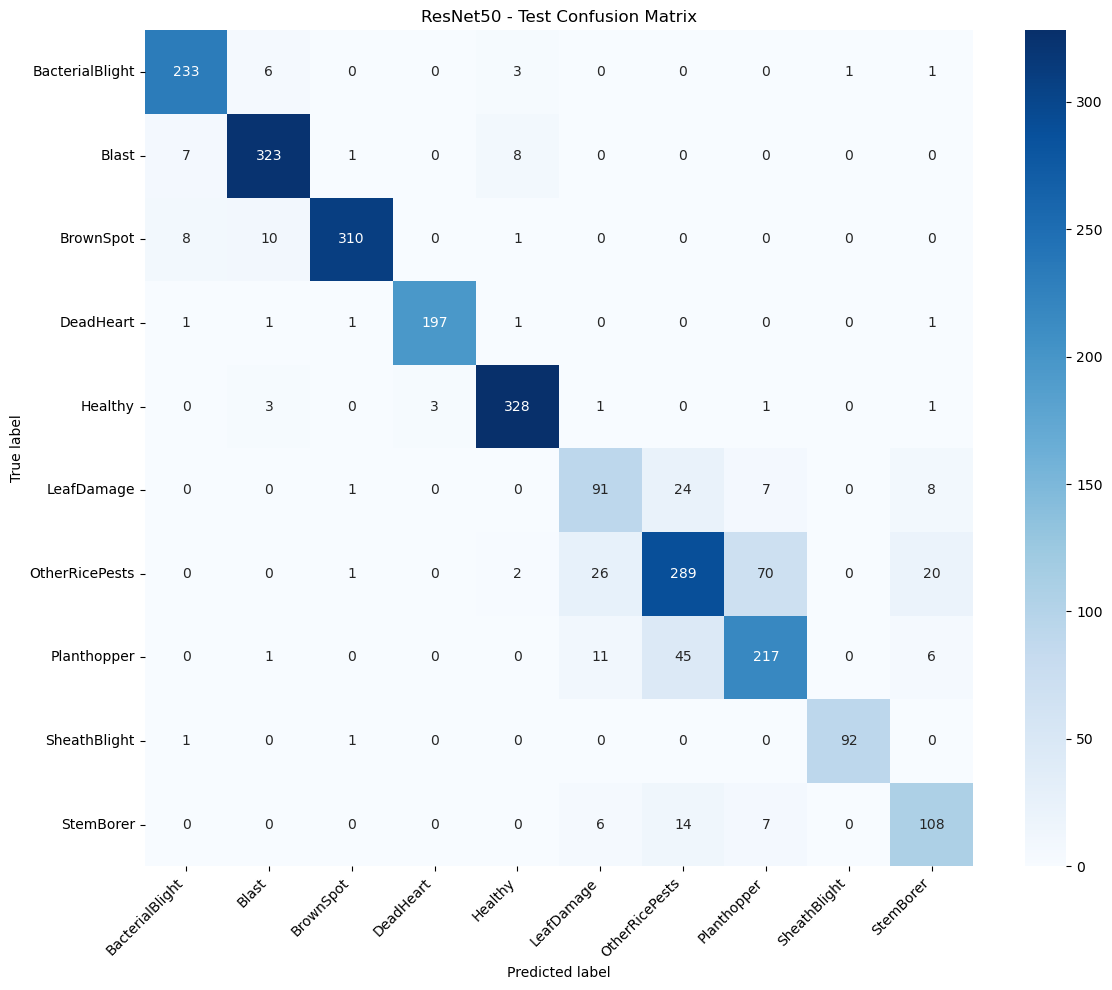

In [27]:
cm = confusion_matrix(
    y_true, y_pred, labels=np.arange(num_classes)
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("ResNet50 - Test Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()